# BeetleCast 02 — Add AlphaEarth embeddings

This notebook compares:

1. **Sentinel-2 baseline**
2. **Sentinel-2 + AlphaEarth embeddings**

It expects:

```text
project_root/
├── hackathon_data/
│   └── raw/
│       └── aef_embeddings/
│           └── ...2021....tif
│           └── ...2022....tif
├── outputs/
│   └── baseline/
│       └── beetlecast_training_table.csv
└── notebooks/
    └── 02_beetlecast_aef_comparison.ipynb
```

The year mapping is leakage-safe:

- 2022 labels use 2021 AEF
- 2023 labels use 2022 AEF


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rasterio

from affine import Affine
from pyproj import CRS
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.transform import from_origin

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PATCH_PIXELS = 5
TEST_FRACTION = 0.25

cwd = Path.cwd()
if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find hackathon_data/")

DATA_ROOT = PROJECT_ROOT / "hackathon_data"
RAW_ROOT = DATA_ROOT / "raw"
BASELINE_ROOT = PROJECT_ROOT / "outputs" / "baseline"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "aef"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/aef


## 1. Load the baseline training table

In [2]:
training_path = BASELINE_ROOT / "beetlecast_training_table.csv"
assert training_path.exists(), (
    "Baseline training table not found. Run 01_beetlecast_baseline_v2.ipynb first."
)

training = pd.read_csv(training_path)

baseline_features = [
    "ndvi_recent",
    "ndre_recent",
    "nbr_recent",
    "ndvi_prior",
    "ndre_prior",
    "nbr_prior",
    "ndvi_change",
    "ndre_change",
    "nbr_change",
    "ndvi_std",
    "ndre_std",
    "valid_fraction",
]

required_columns = {
    "label_year", "patch_row", "patch_col", "target", "spatial_block"
} | set(baseline_features)

missing = required_columns - set(training.columns)
assert not missing, f"Missing columns from baseline table: {missing}"

print("Rows:", len(training))
print(training.groupby(["label_year", "target"]).size())


Rows: 19944
label_year  target
2022        0         7602
            1         2534
2023        0         7356
            1         2452
dtype: int64


## 2. Find the AEF annual TIFFs

In [3]:
aef_tifs = [
    p for p in RAW_ROOT.rglob("*.tif")
    if "aef" in str(p).lower()
    or "alphaearth" in str(p).lower()
    or "embedding" in str(p).lower()
]

print(f"Found {len(aef_tifs)} possible AEF TIFFs:")
for path in aef_tifs:
    print("-", path)

assert aef_tifs, (
    "No AEF TIFFs found. Copy the F3 annual embedding files into "
    "hackathon_data/raw/aef_embeddings/."
)

def infer_year(path):
    match = re.search(r"(20(?:1[7-9]|2[0-5]))", path.name)
    return int(match.group(1)) if match else None

aef_by_year = {}
for path in aef_tifs:
    year = infer_year(path)
    if year is not None:
        aef_by_year.setdefault(year, []).append(path)

print("\nYears discovered:", sorted(aef_by_year))

needed_years = sorted(set(training["label_year"].astype(int) - 1))
missing_years = [year for year in needed_years if year not in aef_by_year]

assert not missing_years, (
    f"Missing required AEF years: {missing_years}. "
    "For the current labels, copy the 2021 and 2022 annual TIFFs."
)

selected_aef = {year: aef_by_year[year][0] for year in needed_years}

print("\nSelected:")
for year, path in selected_aef.items():
    print(year, "->", path)


Found 2 possible AEF TIFFs:
- /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2021.tif
- /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2022.tif

Years discovered: [2021, 2022]

Selected:
2021 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2021.tif
2022 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2022.tif


## 3. Reconstruct the 50 m patch grid

In [4]:
zarr_paths = list(RAW_ROOT.rglob("cube.zarr"))
f3_zarr = [
    p for p in zarr_paths
    if "f3" in str(p).lower()
    or "bark" in str(p).lower()
    or "germany" in str(p).lower()
]
assert f3_zarr or zarr_paths, "No Sentinel-2 cube found"
CUBE_PATH = (f3_zarr or zarr_paths)[0]

ds = xr.open_zarr(CUBE_PATH, chunks="auto")

if float(ds.y.values[0]) < float(ds.y.values[-1]):
    ds = ds.sortby("y", ascending=False)

x = np.asarray(ds.x.values)
y = np.asarray(ds.y.values)

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))

left = float(x.min() - dx / 2)
top = float(y.max() + dy / 2)
base_transform = from_origin(left, top, dx, dy)
patch_transform = base_transform * Affine.scale(PATCH_PIXELS, PATCH_PIXELS)

patch_height = ds.sizes["y"] // PATCH_PIXELS
patch_width = ds.sizes["x"] // PATCH_PIXELS

def infer_cube_crs(dataset):
    try:
        if dataset.rio.crs is not None:
            return CRS.from_user_input(dataset.rio.crs)
    except Exception:
        pass

    if "spatial_ref" in dataset:
        attrs = dataset["spatial_ref"].attrs
        for key in ("crs_wkt", "spatial_ref", "wkt"):
            value = attrs.get(key)
            if value:
                return CRS.from_user_input(value)

    raise ValueError("Could not infer cube CRS")

grid_crs = infer_cube_crs(ds)

print("Patch grid:", patch_height, "rows x", patch_width, "columns")
print("Patch CRS:", grid_crs)
print("Patch transform:", patch_transform)


Patch grid: 252 rows x 213 columns
Patch CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]
Patch transform: | 50.00, 0.00, 354585.00|
| 0.00,-50.00, 5512065.00|
| 0.00, 0.00, 1.00|


## 4. Read and align AEF embeddings

Each annual AEF TIFF is warped directly onto the 50 m modelling grid.  
All available bands are retained.


In [5]:
def read_aef_on_patch_grid(path):
    with rasterio.open(path) as src:
        print(
            f"{path.name}: bands={src.count}, CRS={src.crs}, "
            f"shape={src.height}x{src.width}"
        )

        with WarpedVRT(
            src,
            crs=grid_crs,
            transform=patch_transform,
            width=patch_width,
            height=patch_height,
            resampling=Resampling.bilinear,
            nodata=np.nan,
        ) as vrt:
            data = vrt.read(masked=True).filled(np.nan).astype("float32")

    return data

aef_arrays = {
    year: read_aef_on_patch_grid(path)
    for year, path in selected_aef.items()
}

for year, array in aef_arrays.items():
    print(year, array.shape, "finite fraction:", np.isfinite(array).mean())


aef_F3_Germany_BarkBeetle_2021.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
aef_F3_Germany_BarkBeetle_2022.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
2021 (64, 252, 213) finite fraction: 1.0
2022 (64, 252, 213) finite fraction: 1.0


## 5. Attach AEF bands to each training patch

In [6]:
aef_feature_names = None
aef_values = []

for row in training.itertuples(index=False):
    aef_year = int(row.label_year) - 1
    array = aef_arrays[aef_year]

    r = int(row.patch_row)
    c = int(row.patch_col)

    if r >= array.shape[1] or c >= array.shape[2]:
        values = np.full(array.shape[0], np.nan, dtype="float32")
    else:
        values = array[:, r, c]

    aef_values.append(values)

aef_matrix = np.vstack(aef_values)

aef_feature_names = [
    f"aef_{band_index:02d}"
    for band_index in range(1, aef_matrix.shape[1] + 1)
]

aef_frame = pd.DataFrame(aef_matrix, columns=aef_feature_names)
combined = pd.concat(
    [training.reset_index(drop=True), aef_frame],
    axis=1,
)

print("AEF bands:", len(aef_feature_names))
print("Combined shape:", combined.shape)
print("Rows with complete AEF:", combined[aef_feature_names].notna().all(axis=1).sum())

combined_path = OUTPUT_ROOT / "beetlecast_training_table_with_aef.csv"
combined.to_csv(combined_path, index=False)

print("Saved:", combined_path)


AEF bands: 64
Combined shape: (19944, 82)
Rows with complete AEF: 19944
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/aef/beetlecast_training_table_with_aef.csv


## 6. Use the same blocked split for both models

In [7]:
usable = combined.dropna(
    subset=baseline_features + aef_feature_names + ["spatial_block", "target"]
).copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(
        usable,
        usable["target"],
        usable["spatial_block"],
    )
)

train = usable.iloc[train_idx]
test = usable.iloc[test_idx]

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train positive rate:", train["target"].mean())
print("Test positive rate:", test["target"].mean())


Train rows: 14741
Test rows: 5203
Train positive rate: 0.23207380774709993
Test positive rate: 0.30078800691908514


## 7. Train baseline and AEF models

In [8]:
def fit_and_score(feature_columns, name):
    model = HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )

    weights = compute_sample_weight(
        class_weight="balanced",
        y=train["target"].astype(int),
    )

    model.fit(
        train[feature_columns],
        train["target"].astype(int),
        sample_weight=weights,
    )

    risk = model.predict_proba(test[feature_columns])[:, 1]

    n_select = max(1, int(np.ceil(len(risk) * 0.10)))
    selected = np.argsort(risk)[-n_select:]
    positives = test["target"].to_numpy().astype(int)
    capture = positives[selected].sum() / max(1, positives.sum())

    metrics = {
        "model": name,
        "feature_count": len(feature_columns),
        "pr_auc": average_precision_score(positives, risk),
        "roc_auc": roc_auc_score(positives, risk),
        "top_10_percent_capture": capture,
    }

    return model, risk, metrics

baseline_model, baseline_risk, baseline_metrics = fit_and_score(
    baseline_features,
    "Sentinel-2 baseline",
)

aef_model, aef_risk, aef_metrics = fit_and_score(
    baseline_features + aef_feature_names,
    "Sentinel-2 + AEF",
)

metrics_df = pd.DataFrame([baseline_metrics, aef_metrics])
metrics_df["pr_auc_change"] = metrics_df["pr_auc"] - baseline_metrics["pr_auc"]
metrics_df["capture_change"] = (
    metrics_df["top_10_percent_capture"]
    - baseline_metrics["top_10_percent_capture"]
)

metrics_path = OUTPUT_ROOT / "beetlecast_aef_comparison.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


,model,feature_count,pr_auc,roc_auc,top_10_percent_capture,pr_auc_change,capture_change
0,Sentinel-2 baseline,12,0.706416,0.821303,0.293930,0.000000,0.000000
1,Sentinel-2 + AEF,76,0.885674,0.933734,0.325879,0.179258,0.031949


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/aef/beetlecast_aef_comparison.csv


## 8. Plot the comparison

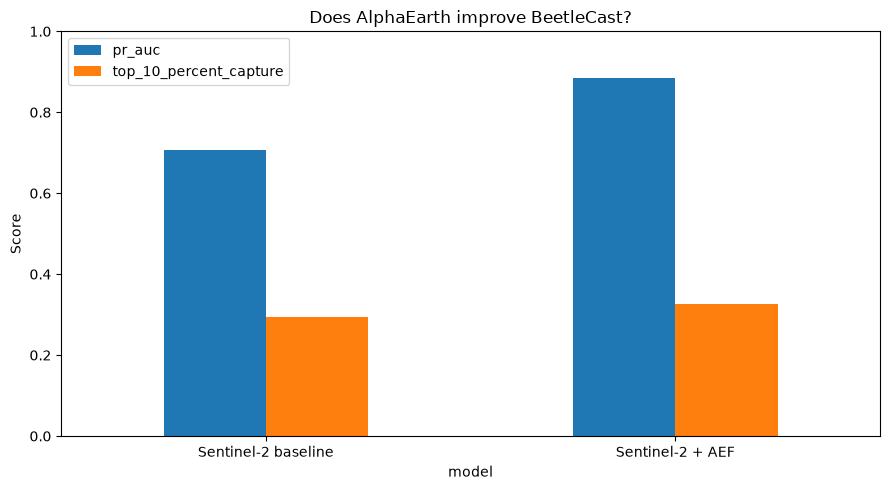

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/aef/beetlecast_aef_comparison.png


In [9]:
plot_df = metrics_df.set_index("model")[
    ["pr_auc", "top_10_percent_capture"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Does AlphaEarth improve BeetleCast?")
plt.tight_layout()

comparison_plot = OUTPUT_ROOT / "beetlecast_aef_comparison.png"
plt.savefig(comparison_plot, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", comparison_plot)


## 9. Inspect AEF importance

In [10]:
all_features = baseline_features + aef_feature_names

importance = permutation_importance(
    aef_model,
    test[all_features],
    test["target"].astype(int),
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": all_features,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_path = OUTPUT_ROOT / "beetlecast_aef_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

display(importance_df.head(20))
print("Saved:", importance_path)


,feature,importance_mean,importance_std
13,aef_02,0.043202,0.002968
64,aef_53,0.034167,0.002641
35,aef_24,0.015386,0.001471
11,valid_fraction,0.015326,0.001331
34,aef_23,0.013264,0.001245
28,aef_17,0.011890,0.001184
71,aef_60,0.011206,0.001112
57,aef_46,0.009327,0.000581
73,aef_62,0.009320,0.000356
48,aef_37,0.008745,0.001243


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/aef/beetlecast_aef_feature_importance.csv


## 10. Final decision

In [11]:
baseline_row = metrics_df.loc[
    metrics_df["model"] == "Sentinel-2 baseline"
].iloc[0]

aef_row = metrics_df.loc[
    metrics_df["model"] == "Sentinel-2 + AEF"
].iloc[0]

print("AEF COMPARISON COMPLETE")
print("-----------------------")
print(f"Baseline PR-AUC: {baseline_row.pr_auc:.3f}")
print(f"AEF PR-AUC: {aef_row.pr_auc:.3f}")
print(f"Baseline top-10% capture: {baseline_row.top_10_percent_capture:.1%}")
print(f"AEF top-10% capture: {aef_row.top_10_percent_capture:.1%}")

if (
    aef_row.pr_auc > baseline_row.pr_auc
    or aef_row.top_10_percent_capture > baseline_row.top_10_percent_capture
):
    print("\nDecision: keep AEF in the competition model.")
else:
    print(
        "\nDecision: do not force AEF into the final model. "
        "Present the ablation honestly and retain the simpler baseline."
    )


AEF COMPARISON COMPLETE
-----------------------
Baseline PR-AUC: 0.706
AEF PR-AUC: 0.886
Baseline top-10% capture: 29.4%
AEF top-10% capture: 32.6%

Decision: keep AEF in the competition model.
